# Chapter 3

## Preparation

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.sampling_bars import dollar_bar
from utils.multiprocess import mpPandasObj

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

In [2]:
dollar_bars.head()

,price,bid,ask,vol,dollar_vol
date,,,,,
2009-09-28 09:32:06,50.7800,50.76,50.78,500,25390.0000
2009-09-28 09:33:54,50.8200,50.80,50.82,100,5082.0000
2009-09-28 09:37:33,50.8299,50.80,50.83,166,8437.7634
2009-09-28 09:41:53,50.8400,50.83,50.84,200,10168.0000
2009-09-28 09:44:09,50.9100,50.91,50.92,1100,56001.0000


In [3]:
dollar_bars['price'] = dollar_bars['price'].sort_index()
dollar_bars['price'] = dollar_bars['price'][~dollar_bars['price'].index.duplicated(keep="last")]

In [4]:
dollar_bars.shape

(903958, 5)

### a. Apply a symmetric CUSUM filter (Chapter 2, Section 2.5.2.1) where the threshold is the standard deviation of daily returns (Snippet 3.1).

In [5]:
def get_daily_vol(close, span0=100):
    """Compute exponentially weighted daily return volatility."""
    close = close.sort_index()
    close = close[~close.index.duplicated(keep="last")]

    prev_pos = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    valid = prev_pos > 0

    current_pos = np.arange(len(close))[valid]
    prev_pos = prev_pos[valid] - 1

    returns = pd.Series(
        close.iloc[current_pos].to_numpy() / close.iloc[prev_pos].to_numpy() - 1,
        index=close.index[current_pos],
        name="daily_vol",
    )
    return returns.ewm(span=span0).std().dropna()

<Axes: xlabel='date'>

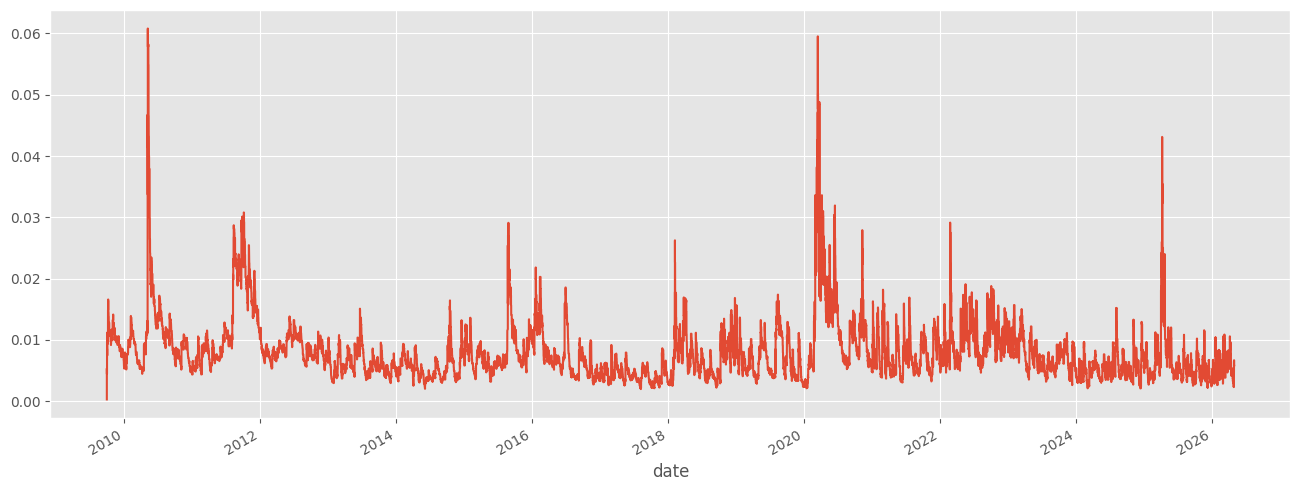

In [6]:
vols = get_daily_vol(dollar_bars['price'], span0=1000)
vols.plot()

In [7]:
vols.head()

date
2009-09-29 09:35:04    0.000288
2009-09-29 09:39:33    0.000393
2009-09-29 09:44:07    0.000937
2009-09-29 09:51:03    0.002640
2009-09-29 09:51:44    0.002682
Name: daily_vol, dtype: float64

In [8]:
def symmetric_cusum_filter(close, threshold):
    """Apply a symmetric CUSUM filter to log returns."""
    close = close.sort_index()
    log_ret = np.log(close).diff().dropna()

    if isinstance(threshold, pd.DataFrame):
        if threshold.shape[1] != 1:
            raise ValueError("threshold DataFrame must have exactly one column")
        threshold = threshold.iloc[:, 0]

    if isinstance(threshold, pd.Series):
        threshold_values = threshold.sort_index().reindex(log_ret.index).ffill().to_numpy()
    else:
        threshold_values = np.full(log_ret.shape[0], threshold)

    s_pos, s_neg = 0.0, 0.0
    t_events = []
    for t, ret, h in zip(log_ret.index, log_ret.to_numpy(), threshold_values):
        if pd.isna(h) or h <= 0:
            continue

        s_pos = max(0.0, s_pos + ret)
        s_neg = min(0.0, s_neg + ret)

        if s_pos > h:
            s_pos = 0.0
            t_events.append(t)
        elif s_neg < -h:
            s_neg = 0.0
            t_events.append(t)
    return pd.DatetimeIndex(t_events)


close = dollar_bars["price"].sort_index()
daily_vol = get_daily_vol(close, span0=1000)
t_events = symmetric_cusum_filter(close, daily_vol)
len(t_events), t_events[:5]

(7465,
 DatetimeIndex(['2009-09-29 09:35:04', '2009-09-29 09:39:33',
                '2009-09-29 09:44:07', '2009-09-29 09:59:17',
                '2009-09-29 10:00:01'],
               dtype='datetime64[us]', freq=None))

### b. Use Snippet 3.4 on a pandas series t1, where numDays = 1.

In [9]:
def get_vertical_bars(close, t_events, num_days=1):
    t1 = close.index.searchsorted(t_events + pd.Timedelta(days=num_days))
    t1 = t1[t1 < close.shape[0]]
    t1 = pd.Series(close.index[t1], index=t_events[:t1.shape[0]]) # NaNs at the end
    return t1

In [10]:
vertical_bars = get_vertical_bars(close, t_events)
vertical_bars

2009-09-29 09:35:04   2009-09-30 09:35:55
2009-09-29 09:39:33   2009-09-30 09:42:17
2009-09-29 09:44:07   2009-09-30 09:44:46
2009-09-29 09:59:17   2009-09-30 10:00:08
2009-09-29 10:00:01   2009-09-30 10:00:08
                              ...        
2026-04-29 15:59:48   2026-04-30 16:00:00
2026-04-30 09:45:47   2026-05-01 09:46:24
2026-04-30 10:11:36   2026-05-01 10:11:39
2026-04-30 10:23:04   2026-05-01 10:23:05
2026-04-30 14:37:51   2026-05-01 14:39:23
Name: date, Length: 7463, dtype: datetime64[us]

### c. On those sampled features, apply the triple-barrier method, where ptSl = [1,1] and t1 is the series you created in point 1.b.

In [11]:
# TRIPLE-BARRIER LABELING METHOD
def apply_pt_sl_on_t1(close, events, pt_sl, molecule):
    """Apply stop loss on t1."""
    events_ = events.copy().loc[molecule]
    out = events_[['t1']].copy(deep=True)

    # upper limit (profit taking)
    if pt_sl[0] > 0:
        pt = pt_sl[0] * events_['target']
    else:
        pt = pd.Series(index=events.index) # NaNs
    
    # lower limit (stop loss)
    if pt_sl[1] > 0:
        sl = -pt_sl[1] * events_['target']
    else:
        sl = pd.Series(index=events.index) #  NaNs
    
    for loc, t1_val in events_['t1'].fillna(close.index[-1]).items():
        df0 = close[loc:t1_val] # path prices
        df0 = (df0 / close[loc] - 1) * events_.at[loc, 'side'] # path linear returns
        out.loc[loc, 'sl'] = df0[df0<sl[loc]].index.min() # earliest stop loss
        out.loc[loc, 'pt'] = df0[df0>pt[loc]].index.min() # earliest profit take

    
    # The output from this function is a pandas dataframe containing 
    # the timestamps (if any) at which each barrier was touched.
    return out

def get_events(close, t_events, pt_sl, target, min_ret, num_threads=1, t1=None, side=None):
    target = target.loc[t_events]
    target = target[target > min_ret]
    if t1 is None:
        t1 = pd.Series(pd.NaT, index=t_events)
    
    if side is None:
        side_, pt_sl_ = pd.Series(1.0, index=target.index), [pt_sl[0], pt_sl[0]]
    else:
        side_, pt_sl_ = side.loc[target.index], pt_sl[:2]
    
    events = pd.concat({'t1': t1, 'target': target, 'side': side_}, axis=1).dropna(subset=['target'])
    df0 = mpPandasObj(func=apply_pt_sl_on_t1, pdObj=('molecule', events.index), numThreads=num_threads, close=close, events=events, pt_sl=pt_sl_)
    events['t1'] = df0.dropna(how='all').min(axis=1)
    if side is None:
        events = events.drop('side', axis=1)
    
    # store for later
    events['pt'] = pt_sl_[0]
    events['sl'] = pt_sl_[1]

    return events

In [12]:
dollar_bars['abs_return'] = dollar_bars['price'].pct_change().abs()

events = get_events(dollar_bars['price'], t_events=t_events, pt_sl=[1,1], t1=vertical_bars, num_threads=1, target=dollar_bars['abs_return'], min_ret=0.01)

In [15]:
events

,t1,target,pt,sl
2009-10-01 16:16:36,2009-10-02 09:29:12,0.010373,1,1
2009-10-02 09:29:12,2009-10-05 09:31:33,0.019608,1,1
2009-10-14 09:29:46,2009-10-15 09:30:44,0.013862,1,1
2009-10-29 09:10:57,2009-10-30 09:31:48,0.015899,1,1
2009-11-23 09:30:25,2009-11-24 09:36:18,0.011311,1,1
...,...,...,...,...
2025-06-26 09:30:00,2025-06-27 09:30:00,0.028066,1,1
2026-01-20 09:30:00,2026-01-21 09:30:00,0.010080,1,1
2026-03-03 09:30:00,2026-03-04 09:30:00,0.013342,1,1
2026-03-30 09:28:10,2026-03-30 15:07:00,0.013875,1,1
